In [1]:
import numpy as np
import matplotlib.pyplot as plt

with open("data_files/belgian_temp.npy", "rb") as fh:
    df_arr = np.load(fh)
    year_range_arr = np.load(fh)
    station_name_arr = np.load(fh)
    files_arr = np.load(fh)

In [2]:
# PLOT 1 D ARRAY
def plot(array, year_range_arr):
    fig, ax = plt.subplots(1,1)
    new_arr = np.pad(year_range_arr, (0, 1), mode='constant', constant_values=2024)

    ax.plot(new_arr, array)

    # Improve x-axis ticks (show every 10 years)
    ax.set_xticks(np.arange(1880, 2024, 10))  
    ax.set_xlim(1880, 2023)  # Explicitly set range

    # Add labels if needed
    ax.set_xlabel("Index")
    ax.set_ylabel("Average temp for Belgium")
    ax.set_title("Flattened Average Values")
    # THERE IS A MEASUREMENT OF -999C° so a limit of y-ax
    ax.set_ylim(-20,20)

    # Display the plot
    plt.tight_layout()
    plt.show()

1. Generate an array with for every year and month the average temperature observed in all stations.
2. How many months in the whole period had an average temperature below 0?
3. Which were on average the warmest and coldest year in Belgium?
4. When was the biggest temperature difference observed between consecutive months in Belgium?
5. Use a sliding window to compute the average temperature per 12 months

In [3]:
# 1. Generate an array with for every year and month the average temperature observed in all stations.
df_avg = np.nanmean(df_arr, axis=0)  #shape (145, 12)
df_flatten = df_avg.reshape(-1,)    #shape (1740,)

/var/folders/ln/gbs9zy0n4fs374gdtp6rp1xw0000gn/T/ipykernel_73721/3728817197.py:2: RuntimeWarning: Mean of empty slice
  df_avg = np.nanmean(df_arr, axis=0)  #shape (145, 12)


In [4]:
# 2. How many months in the whole period had an average temperature below 0?
avg_temp_below_0 = np.sum(df_avg < 0)
print(f"Months with average temperature below 0°C: {avg_temp_below_0} months of the {df_avg.size} months")

Months with average temperature below 0°C: 290 months of the 1740 months


[1930] had the lowest average temparture of -10.335416666666669C°


/var/folders/ln/gbs9zy0n4fs374gdtp6rp1xw0000gn/T/ipykernel_73721/1195273098.py:2: RuntimeWarning: Mean of empty slice
  avg_year = np.nanmean(df_avg, axis=1) #SHAPE (145,)


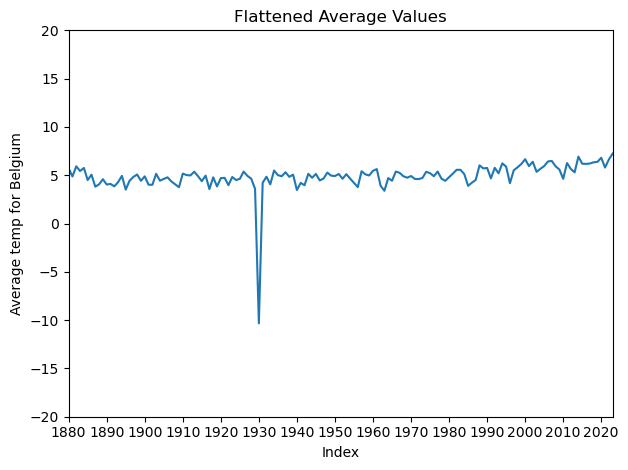

In [5]:
#3. Which were on average the warmest and coldest year in Belgium?
avg_year = np.nanmean(df_avg, axis=1) #SHAPE (145,)
min_avg_year = np.nanmin(avg_year)

year_idx = np.where(avg_year == min_avg_year)
print(f"{year_range_arr[year_idx]} had the lowest average temparture of {min_avg_year}C°")
plot(avg_year, year_range_arr)

In [6]:
# 4. When was the biggest temperature difference observed between consecutive months in Belgium?
df_avg_diff = np.abs(np.diff(df_avg, axis=1))  #SHAPE (145, 11)
max_df_avg_diff = np.nanmax(df_avg_diff)
year_idx, month_idx = np.where(df_avg_diff == max_df_avg_diff)
print(f"The biggest difference observed between months is {max_df_avg_diff} in "
      f"{year_range_arr[year_idx]} between months {month_idx+1} and {month_idx+2}")


The biggest difference observed between months is 65.71875 in [1930] between months [3] and [4]


In [7]:
#5. Use a sliding window to compute the average temperature per 12 months
window_size = 12
smoothed_data = np.convolve(df_flatten, np.ones(window_size)/window_size, mode='valid') 
# SHAPE (1729,) => 1740 - 12 + 1 mode= valid
smoothed_data.shape

(1729,)

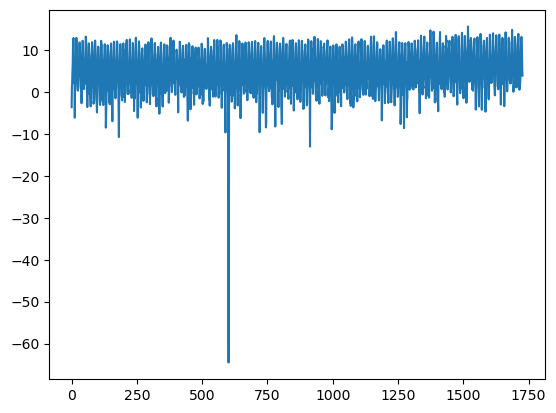

In [8]:
plt.plot(df_flatten)

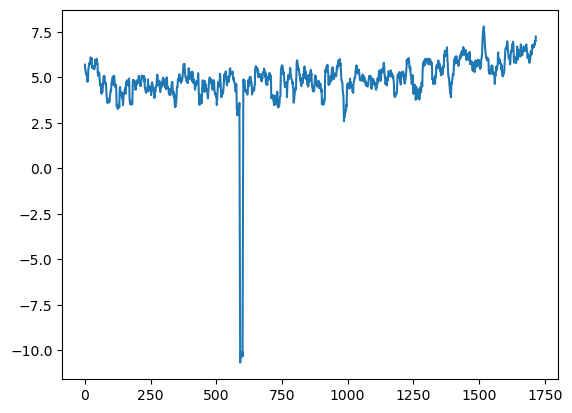

In [9]:
plt.plot(smoothed_data)
